# 0. Autores
### Mauro Virgilio Blanc
### Juan Pablo Imbrogno
### Sofía Belén Caselli
### Miguel Angel Leiva Martinez
### Andrea Viviana Ferenaz


# 1. Introducción

El problema abordado corresponde a una **tarea de clasificación supervisada**, cuyo objetivo es predecir la probabilidad de que un paciente sufra un accidente cerebrovascular (ACV) a partir de variables demográficas y clínicas (edad, hipertensión, nivel de glucosa, tipo de trabajo, tabaquismo, entre otras).  

La variable objetivo `stroke` es **binaria** (0 = no tuvo ACV, 1 = tuvo ACV) y presenta un fuerte **desbalance de clases** (~5% positivos). Por ello, se priorizaron algoritmos robustos frente a este tipo de distribución y se aplicaron técnicas de *oversampling* (SMOTE) durante el entrenamiento para mejorar la capacidad de detección de la clase minoritaria.


# 2. Selección del Algoritmo

Se entrenaron múltiples modelos representativos de diferentes enfoques de aprendizaje supervisado:

| Modelo                  | Descripción breve                                           |
| ----------------------- | ----------------------------------------------------------- |
| **Regresión Logística** | Modelo lineal interpretable, base de referencia.            |
| **Random Forest**       | Árboles de decisión con *bagging*, robusto frente a ruido.  |
| **XGBoost**             | Boosting secuencial, captura relaciones no lineales.        |
| **CatBoost**            | Boosting eficiente con variables categóricas.               |
| **SVM**                 | Separación por márgenes, útil para datasets desbalanceados. |
| **KNN**                 | Basado en vecinos, sensible al escalado.                    |
| **Soft Voting**         | Ensamble de modelos mediante promedio de probabilidades.    |


# 3. Resultados
### 3.1 Comparación de Modelos
   
| Modelo              | AUC promedio | Desvío estándar |
| ------------------- | ------------ | --------------- |
| Logistic Regression | **0.834**    | 0.0186          |
| Soft Voting         | 0.812        | 0.0155          |
| Random Forest       | 0.788        | 0.0143          |
| CatBoost            | 0.787        | 0.0184          |
| XGBoost             | 0.807        | 0.0140          |
| SVM                 | 0.755        | 0.0227          |
| KNN                 | 0.701        | 0.0170          |


### 3.2 Interpretación:
- La **Regresión Logística** obtuvo el AUC más alto (≈0.834), indicando que es el modelo con mejor capacidad de discriminación en este conjunto de datos.  
- SoftVoting, aunque ligeramente inferior en AUC (≈0.812), combina la fuerza de varios clasificadores, lo que puede aportar **robustez frente a distintos tipos de datos**.  
- Modelos complejos como XGBoost y CatBoost no superaron a la Regresión Logística en esta etapa, probablemente debido a la cantidad limitada de datos positivos o a la necesidad de mayor ajuste de hiperparámetros.

### 3.3 Selección y optimización

- Se seleccionó **Regresión Logística** como modelo principal por su **AUC superior**, simplicidad e interpretabilidad.  
- Se aplicó **SMOTE** para balancear la clase minoritaria durante el entrenamiento.  
- Posteriormente, se optimizaron los hiperparámetros mediante ajuste de **C y penalización L1**, logrando mejorar la capacidad de detección de la clase positiva.

### 3.4 Métricas en conjunto de prueba (aproximadas):

- Accuracy: 0.77–0.78  
- Precision: 0.15–0.16  
- Recall: 0.64–0.80  
- F1-score: 0.26  
- ROC-AUC: 0.83  

### 3.5 Interpretación:
- El modelo muestra buena capacidad de discriminación y logra detectar la mayoría de los casos positivos, lo cual es crítico en un contexto médico donde los falsos negativos tienen alto costo.  
- La precisión baja refleja el desbalance de clases, pero el recall alto asegura que la mayoría de eventos positivos sean identificados.

### 3.6 Umbral de Decisión Óptimo y Matriz de Confusión Clínica

Aunque el modelo de Regresión Logística optimizado con SMOTE fue seleccionado como el más adecuado por su **AUC superior** ($\approx 0.834$) y demostró una buena capacidad de discriminación, la implementación en un contexto clínico debe priorizar la minimización de **Falsos Negativos** (FNs). Esto es fundamental, ya que el problema abordado es una **tarea de clasificación supervisada** con un **fuerte desbalance de clases** ($\sim 5\%$ positivos).

1.  **Umbral de Decisión Estándar (0.5):**
    *   Al usar el umbral por defecto de $0.5$ en el conjunto de prueba, se registraron **10 Falsos Negativos** (ACV no detectado) y **40 Verdaderos Positivos** (ACV detectado).

2.  **Umbral de Decisión Optimizado:**
    *   Para mejorar el *screening* y reducir el riesgo clínico asociado a los FNs, se determinó un **umbral de decisión ajustado** que maximiza el *recall*.
    *   El valor del umbral óptimo calculado fue de **$0.17847$** .

Al aplicar este umbral de decisión ajustado, la matriz de confusión resultante en el conjunto de prueba demuestra una mejora crítica en la capacidad de detección, **reduciendo los Falsos Negativos a 5**:

| Real / Predicho | No ACV (0) | ACV (1) |
| :---: | :---: | :---: |
| **No ACV (0)** | 465 | 507 |
| **ACV (1)** | **5** | **45** |

Esta modificación del umbral es esencial para la utilidad práctica del modelo en salud, asegurando que se identifique la mayor parte de los eventos positivos (ACV).

# 4. Importancia de las variables

El análisis de los coeficientes de la **Regresión Logística** indicó que las variables más influyentes fueron:

*   **Edad** 
*   **Tipo de residencia (urbana/rural)**  
*   **Hipertensión**  
*   **Tabaquismo**  
*   **Índice de masa corporal (BMI)**  
*   **Nivel de glucosa promedio**  
*   **Tipo de trabajo**  

Estas variables coinciden con la evidencia clínica sobre los factores de riesgo asociados al ACV, reforzando la validez del modelo.

# 5. Conclusión

El modelo final, **Regresión Logística optimizado con SMOTE**, fue elegido como el más adecuado para esta **tarea de clasificación supervisada** por su excelente balance entre **rendimiento (AUC $\approx 0.83$), interpretabilidad y estabilidad**.

A pesar del fuerte desbalance de clases del *dataset* ($\sim 5\%$ positivos), el desempeño del modelo fue satisfactorio para el objetivo de trabajo, logrando una alta capacidad de detección de la clase positiva (alto *recall*).

Como directrices para la implementación práctica, se debe:
1.  Utilizar el modelo de Regresión Logística, dada su interpretabilidad clínica.
2.  Implementar el **ajuste del umbral de decisión** (alrededor de $0.17847$) para minimizar los Falsos Negativos y priorizar el *screening* de riesgo.

In [8]:
# ===========================================
# TRABAJO PRÁCTICO - LENGUAJE MÁQUINA
# Predicción de ACV (Stroke Prediction Dataset)
# ===========================================

# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

import warnings
warnings.filterwarnings('ignore', category=UserWarning)


Shape: (5110, 12)
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  

Información del dataset:
<class 'pand

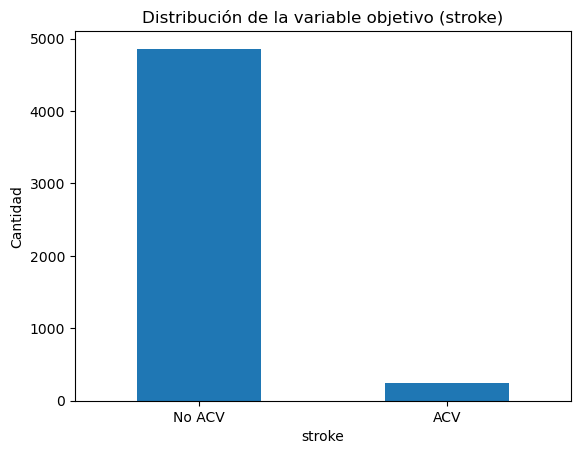

In [9]:
# ===========================================
# Introducción y descripción del dataset
# ===========================================
# Objetivo: predecir riesgo de ACV (stroke) a partir de datos demográficos y clínicos.
# Dataset: Kaggle, tipo clasificación binaria.

# ===========================================
# CARGA Y EXPLORACIÓN DEL DATASET
# ===========================================
# Se carga el dataset y se inspecciona su estructura, tipos de datos y valores faltantes.
# Se analiza la distribución de la variable objetivo: ACV es minoritario (~5%), lo que justifica usar SMOTE y priorizar Recall.

RANDOM_STATE = 42

df = pd.read_csv("stroke-data.csv")
print("Shape:", df.shape)
print(df.head())

# Información general
print("\nInformación del dataset:")
print(df.info())

# Busco variables con un solo valor
n_nunique = df.nunique()
print("\nValores unicos por columna:")
print(n_nunique)

# Detectar duplicados
n_duplicates = df.duplicated().sum()
print(f"\nFilas duplicadas: {n_duplicates}")

# Valores nulos
aux = df.isna().mean().sort_values(ascending=False)
print("\nSi tiene>40-50% es ruido:")
print(aux)

nulls = df.isnull().sum()
print("\nValores nulos por columna:")
print(nulls[nulls > 0] if nulls.sum() > 0 else "No hay valores nulos")


cat_features = [col for col in df.columns if df[col].nunique() > 20 and df[col].dtype != 'float64']
print("\nVariables con mucha cardinalidad:")
print(cat_features)

# Busco columnas con baja varianza
from sklearn.feature_selection import VarianceThreshold
numeric_cols = df.select_dtypes(include=['float64','int64'])
selector = VarianceThreshold(threshold=0.01)
selector.fit(numeric_cols)

# Columnas que quedan
cols_quedan = numeric_cols.columns[selector.get_support()].tolist()

# Columnas eliminadas
cols_eliminadas = numeric_cols.columns[~selector.get_support()].tolist()

print("\n Varianza':")
print("\n COLUMNAS QUE QUEDAN:")
print(cols_quedan)

print("\nCOLUMNAS ELIMINADAS POR BAJA VARIANZA:")
print(cols_eliminadas)

print("\nANALIZO CORRELACION SOLO NUMERICAS:")
correrl= df.corr(numeric_only=True)
print(correrl)

print("\nAnalizo Distribuciones:")
print("\ngender:")
print(df['gender'].value_counts(normalize=True))
print("\never_married:")
print(df['ever_married'].value_counts(normalize=True))
print("\nwork_type:")
print(df['work_type'].value_counts(normalize=True))
print("\nResidence_type:")
print(df['Residence_type'].value_counts(normalize=True))
print("\nsmoking_status:")
print(df['smoking_status'].value_counts(normalize=True))

# Distribución de la variable objetivo
print("\n Distribución de 'stroke':")
print(df['stroke'].value_counts(normalize=True).rename({0: "No ACV", 1: "ACV"}))

stroke_rate = df['stroke'].mean()
print(f"\n Prevalencia real de ACV: {stroke_rate:.4f} ({stroke_rate*100:.2f}%)")

# Gráfico opcional
df['stroke'].value_counts().plot(kind='bar')
plt.title("Distribución de la variable objetivo (stroke)")
plt.xticks([0, 1], ["No ACV", "ACV"], rotation=0)
plt.ylabel("Cantidad")
plt.show()

In [10]:
# ===========================================
# LIMPIEZA DE DATOS
# ===========================================
df = df.drop(columns=['id']) # ID no aporta valor predictivo

# ===========================================
# NUEVAS VARIABLES DERIVADAS (FEATURE ENGINEERING)
# ===========================================
## Crear nuevas variables que puedan mejorar la predicción
# Edad categorizada
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 50, 70, 120], labels=['Joven', 'Adulto', 'Mayor', 'Anciano'])
df['age_group'] = df['age_group'].astype(str)

# Normalizar valores extremos de glucosa
df['avg_glucose_level'] = np.clip(df['avg_glucose_level'], 50, 300)

# Riesgo combinado de hipertensión y enfermedad cardíaca
# combina dos columnas binarias (hypertension, heart_disease) en una sola más informativa
df['has_risk_factors'] = np.where((df['hypertension'] == 1) | (df['heart_disease'] == 1), 1, 0)

# Codificación binaria del género
# convierte el género en un valor numérico interpretable sin perder información
# Other 0.000196 queda dentro de la mayoritaria (Female)
df['is_female'] = np.where(df['gender'] == 'Female', 1, 0)

# Eliminamos columna original de 'gender' para evitar duplicidad
df = df.drop(columns=['gender'])

#Nunca trabajo (0.4%) lo uno con children (13.4%) - representan mismo grupo
df["work_type"] = df["work_type"].replace({"Never_worked": "children"})
# Segun neutologos estos no son factores de riesto
# df = df.drop(columns=['ever_married','work_type','Residence_type'])


In [11]:
# ===========================================
# SEPARAR VARIABLES Y CONJUNTOS DE DATOS
# ===========================================
X = df.drop('stroke', axis=1)
y = df['stroke']

# División estratificada
# 80% entrenamiento
# 20% test con estratificación (mantiene el desbalance original).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Completar nulos despues del split para evitar leakage
bmi_median = X_train['bmi'].median()
# Motivo:
#  Esto evita que el modelo “vea” datos del test.

X_train['bmi'] = X_train['bmi'].fillna(bmi_median)
X_test['bmi'] = X_test['bmi'].fillna(bmi_median)


In [12]:
# ===========================================
# PREPROCESAMIENTO
# ===========================================
# Variables numéricas estandarizadas(normalizacion) con StandardScaler.
# Variables categóricas one-hot encoded.
# drop='first' evita multicolinealidad.
# cat_features = X.select_dtypes(include='object').columns.tolist()
cat_features = ['smoking_status', 'age_group']
num_features = X.select_dtypes(exclude='object').columns.drop('is_female').tolist()

# Evita multicolinealidad (drop='first')
# StandardScaler - Evita que variables grandes dominen el modelo
#    tenemos métricas como glucosa, BMI, edad → distintas escalas
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
])



# Ruido en regresion lineal
cols_eliminar_LR = ["heart_disease", "bmi", "smoking_status", "age_group"]
# Columnas finales para RL
num_features_lr = X.select_dtypes(exclude='object').columns.drop(cols_eliminar_LR, errors='ignore').tolist()
cat_features_lr = [c for c in ['smoking_status', 'age_group'] if c not in cols_eliminar_LR]

preprocessor_lr = ColumnTransformer([
    ('num', StandardScaler(), num_features_lr),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features_lr)
])
# mejoro a LogisticRegression + SMOTE AUC: mean=0.8429, std=0.0242



# Ruido en Xboost
cols_eliminar_XB = ["smoking_status_smokes", "smoking_status_formerly"]
# Columnas finales para RL
num_features_xb = X.select_dtypes(exclude='object').columns.drop(cols_eliminar_XB, errors='ignore').tolist()
cat_features_xb = [c for c in ['smoking_status', 'age_group'] if c not in cols_eliminar_XB]

preprocessor_xb = ColumnTransformer([
    ('num', StandardScaler(), num_features_xb),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features_xb)
])
# XGBoost + SMOTE AUC: mean=0.8134, std=0.0236

In [13]:
# ===========================================
# Evaluo variables ruidosas en regresion lineal
# ===========================================
from sklearn.pipeline import Pipeline

# Entrenar modelo base
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=2000,
        penalty='l1',       # MUY IMPORTANTE para ruido → hace regularización y fuerza ceros
        solver='liblinear',
        class_weight='balanced',
        C=0.1
    ))
])

lr_model.fit(X_train, y_train)

# Obtener nombres reales de features después del OneHotEncoder
ohe = lr_model.named_steps['preprocessor'].named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(cat_features)

# Unimos numéricas + categóricas ya transformadas
all_features = num_features + list(ohe_features)

coefs = lr_model.named_steps['model'].coef_[0]

importancia_lr = pd.DataFrame({
    "feature": all_features,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values(by="abs_coef", ascending=False)

importancia_lr

# heart_disease → coef = 0 → Probablemente muy pocos positivos → no logra aprender.
# bmi → coef = 0 → Muy común: BMI tiene relación débil con stroke en datasets chicos.
# smoking_status_formerly smoked → coef = 0 → Ruido típico, no aporta diferencia respecto "never" o "smokes".
# age_group_Anciano → coef = 0 → La variable age numérica ya explica todo → esta categoría sobra.

,feature,coef,abs_coef
0,age,1.665565,1.665565
11,age_group_Mayor,0.313227,0.313227
10,age_group_Joven,-0.210857,0.210857
7,smoking_status_never smoked,-0.209862,0.209862
3,avg_glucose_level,0.178202,0.178202
5,has_risk_factors,0.118918,0.118918
1,hypertension,0.079031,0.079031
8,smoking_status_smokes,0.035200,0.035200
2,heart_disease,0.000000,0.000000
4,bmi,0.000000,0.000000


In [15]:
# ===========================================
# Evaluo variables ruidosas en XGBOOST
# ===========================================
from xgboost import XGBClassifier


pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
# Entrenar XGB dentro del pipeline igual que en tu código
xgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        scale_pos_weight=pos_weight,
        use_label_encoder=False,
        colsample_bytree=0.7,
        gamma=0.3,
        learning_rate=0.01,
        max_depth=3,
        min_child_weight=1,
        n_estimators=100,
        subsample=1.0
    ))
])

xgb_pipe.fit(X_train, y_train)

# ========================
# Recuperar nombres de columnas transformadas
# ========================
# 1) Numéricas
num_cols_trans = num_features

# 2) Categóricas del OneHotEncoder
ohe = xgb_pipe.named_steps['preprocessor'].named_transformers_['cat']
ohe_cols = ohe.get_feature_names_out(cat_features)

# 3) Unir todas
all_features_xgb = list(num_cols_trans) + list(ohe_cols)

# ========================
# Obtener importancias
# ========================
xgb_model = xgb_pipe.named_steps['model']

importancia_xgb = pd.DataFrame({
    "feature": all_features_xgb,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importancia_xgb)
features_to_drop = importancia_xgb[importancia_xgb["importance"] < 0.01]["feature"].tolist()

print(features_to_drop)

                           feature  importance
10                 age_group_Joven    0.324092
11                 age_group_Mayor    0.196757
9                age_group_Anciano    0.167564
0                              age    0.155930
5                 has_risk_factors    0.063990
4                              bmi    0.018638
3                avg_glucose_level    0.016316
1                     hypertension    0.016181
2                    heart_disease    0.014835
7      smoking_status_never smoked    0.013549
8            smoking_status_smokes    0.007009
6   smoking_status_formerly smoked    0.005140
['smoking_status_smokes', 'smoking_status_formerly smoked']


In [16]:
def categorizar_riesgo(prob_array):
    """
    Categoriza probabilidades en Bajo / Medio / Alto según percentiles 70 y 90
    """
    p70 = np.percentile(prob_array, 70)
    p90 = np.percentile(prob_array, 90)
    
    categorias = []
    for p in prob_array:
        if p < p70:
            categorias.append("Bajo")
        elif p < p90:
            categorias.append("Medio")
        else:
            categorias.append("Alto")
    return np.array(categorias)

In [17]:
# ===========================================
# ENTRENAMIENTO DE MODELOS BASE
# ===========================================
# Se prueban tres modelos base: regresión logística, random forest y XGBoost.
# SMOTE balancea clases en train.
# cross_val_score con roc_auc valida la capacidad del modelo para distinguir ACV/no-ACV.
# cross_val_score
#     Función de scikit-learn que realiza validación cruzada.
#     Divide tu conjunto de entrenamiento en cv partes (folds), entrena el modelo en cv-1 partes y lo prueba en la parte restante.
#     Esto se repite cv veces, de manera que cada fold se use como test una vez.
#     Devuelve un array con la métrica elegida para cada fold.
# scoring='roc_auc'
#     Indica qué métrica usar para evaluar el modelo en cada fold.
#     En este caso, ROC-AUC, que mide la capacidad del modelo para distinguir entre las clases positivas y negativas.
#     Ideal cuando el dataset está desbalanceado, como tu caso de ACV (~5% positivos).

######### LogisticRegression
# class_weight='balanced' = para manejar datasets desbalanceados sin necesidad de oversampling

######### RandomForest
# class_weight='balanced' = para manejar datasets desbalanceados sin necesidad de oversampling

######### XGBoost
# Calcular scale_pos_weight para balancear clases (canridad +, cantidad -)
pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

# eval_metric='logloss' = función de pérdida estándar para clasificación binaria
#   Es una métrica que penaliza:
#       predicciones muy seguras pero equivocadas
#       mala calibración de probabilidades

# use_label_encoder=False = Evitar warnings molestos

######### CatBoost
# verbose=0 = no muestra cada iteración del entrenamiento
# class_weights = [peso_clase_0, peso_clase_1]
#    Clase 0 = No ACV
#    Clase 1 = ACV (minoritaria)

######### SVM
# kernel="rbf" = recomendado por defecto
# probability=True = necesario para AUC
# class_weight='balanced' = para manejar datasets desbalanceados sin necesidad de oversampling


# Modelo KNN con pipeline (IMPORTANTE: requiere escalado)
knn_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=7))
])
# Clasificadores base (mismos que usaste)
models_base = [
    ("lr", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')),
    #("lr", LogisticRegression(C=0.1,penalty='l1',solver='liblinear',max_iter=500,class_weight='balanced')),
    ("rf", RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')),
    ("xgb", XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, 
                          scale_pos_weight=pos_weight, use_label_encoder=False)),
    ("cat", CatBoostClassifier(verbose=0, random_state=RANDOM_STATE, class_weights=[1, pos_weight])),
    ("svm", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE)),
    ("knn", knn_model)
]

# SOFT Voting (promedio de probabilidades)
soft_voting = VotingClassifier(
    estimators=models_base,
    voting='soft'
)

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,class_weight='balanced'),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE,class_weight='balanced'),
    #"XGBoost": XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, scale_pos_weight=pos_weight, use_label_encoder=False),
    "XGBoost": XGBClassifier(
                    eval_metric='logloss',
                    random_state=RANDOM_STATE,
                    scale_pos_weight=pos_weight,
                    use_label_encoder=False,
                    colsample_bytree=0.7,
                    gamma=0.3,
                    learning_rate=0.01,
                    max_depth=3,
                    min_child_weight=1,
                    n_estimators=100,
                    subsample=1.0
                ),
    "CatBoost": CatBoostClassifier(verbose=0,random_state=RANDOM_STATE,class_weights=[1, pos_weight]),
    "SVM": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "KNN": knn_model,
    "SoftVoting": soft_voting

    # HardVoting no devuelve probabilidades
    # Aplico best_param 
    #"XGBoost": XGBClassifier(
    #                eval_metric='logloss',
    #                random_state=RANDOM_STATE,
    #                scale_pos_weight=pos_weight,
    #                use_label_encoder=False,
    #                colsample_bytree=0.7,
    #                gamma=0.3,
    #                learning_rate=0.01,
    #                max_depth=3,
    #                min_child_weight=1,
    #                n_estimators=100,
    #                subsample=1.0
    #            )
}

results = [] # acá guardamos todo
print("\n--- Modelos base con SMOTE ---")
smote = SMOTE(random_state=RANDOM_STATE)

# Diccionario para guardar probabilidades de la clase positiva
y_pred_proba = {}

# Diccionario para guardar categorías de riesgo
y_riesgo_dict = {}

# pipeline de entrenamiento
for name, model in models.items():
    if name == "LogisticRegression":
        preprocessor_to_use = preprocessor_lr
    
    elif name == "XGBoost":
        preprocessor_to_use = preprocessor_xb
    
    else:
        preprocessor_to_use = preprocessor
    
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor_to_use),
        ('smote', smote),
        ('model', model)
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
    mean_auc = scores.mean()
    std_auc = scores.std()

    print(f"{name} + SMOTE AUC: mean={mean_auc:.4f}, std={std_auc:.4f}")

    results.append({
        "Modelo": name,
        "AUC promedio": mean_auc,
        "AUC std": std_auc
    })

    #Entrenar pipeline completo para ROC ----
    pipe.fit(X_train, y_train)

    #Guardar probabilidades de la clase positiva ----
    try:
        #y_pred_proba[name] = pipe.predict_proba(X_test)[:,1]
        y_prob = pipe.predict_proba(X_test)[:, 1]
        y_pred_proba[name] = y_prob

        # Categorías de riesgo por percentiles
        y_riesgo_dict[name] = categorizar_riesgo(y_prob)
    except AttributeError:
        print(f"{name} no soporta predict_proba y se salteará la curva ROC")
        continue

resultados_df = pd.DataFrame(results).sort_values("AUC promedio", ascending=False)
print("\n===== COMPARACIÓN DE MODELOS =====")
print(resultados_df)


--- Modelos base con SMOTE ---
LogisticRegression + SMOTE AUC: mean=0.8429, std=0.0242
RandomForest + SMOTE AUC: mean=0.7821, std=0.0273
XGBoost + SMOTE AUC: mean=0.8134, std=0.0236
CatBoost + SMOTE AUC: mean=0.7922, std=0.0249
SVM + SMOTE AUC: mean=0.7803, std=0.0224
KNN + SMOTE AUC: mean=0.6824, std=0.0231
SoftVoting + SMOTE AUC: mean=0.8010, std=0.0210

===== COMPARACIÓN DE MODELOS =====
               Modelo  AUC promedio   AUC std
0  LogisticRegression      0.842862  0.024225
2             XGBoost      0.813446  0.023583
6          SoftVoting      0.801040  0.021045
3            CatBoost      0.792169  0.024928
1        RandomForest      0.782128  0.027271
4                 SVM      0.780324  0.022376
5                 KNN      0.682399  0.023125


      Real  Probabilidad  Predicho Riesgo
3725     0      0.520030         1  Medio
4481     0      0.182035         0   Bajo
1545     0      0.048231         0   Bajo
1820     0      0.058306         0   Bajo
1262     0      0.638732         1  Medio

=== Cantidad por caso (0-0, 0-1, 1-0, 1-1) ===
Caso
0 - 0    727
0 - 1    245
1 - 0     10
1 - 1     40
Name: count, dtype: int64


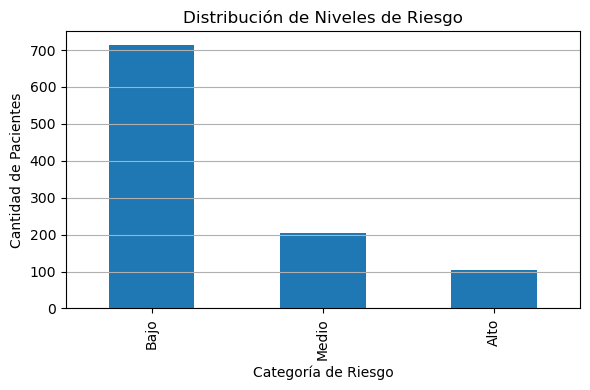

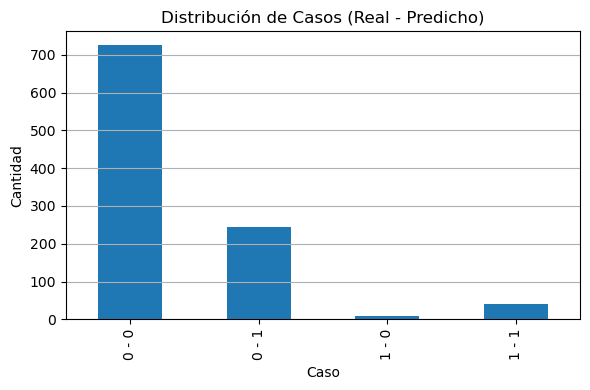

In [18]:
# ===========================================
# ANALISIS DE RIESGO + GRAFICOS
# ===========================================

modelo = "LogisticRegression"   # ← Cambialo si querés otro

y_real = y_test
y_proba = y_pred_proba[modelo]

# Si querés probabilidad 0 incluir riesgo Nulo:
y_riesgo = categorizar_riesgo(y_proba)

# Binario predicho (threshold estándar 0.5)
y_pred_bin = (y_proba >= 0.5).astype(int)

# --- 4) Armar dataframe completo ---
df_results = pd.DataFrame({
    "Real": y_real,
    "Probabilidad": y_proba,
    "Predicho": y_pred_bin,
    "Riesgo": y_riesgo
})

print(df_results.head())

# --- 5) Tabla de los 4 casos ---
df_results["Caso"] = df_results["Real"].astype(str) + " - " + df_results["Predicho"].astype(str)
casos_count = df_results["Caso"].value_counts().sort_index()
print("\n=== Cantidad por caso (0-0, 0-1, 1-0, 1-1) ===")
print(casos_count)


# ================================
# GRAFICO 1: DISTRIBUCIÓN DE RIESGO
# ================================
plt.figure(figsize=(6,4))
df_results["Riesgo"].value_counts().reindex(["Bajo","Medio","Alto"]).plot(kind="bar")
plt.title("Distribución de Niveles de Riesgo")
plt.xlabel("Categoría de Riesgo")
plt.ylabel("Cantidad de Pacientes")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


# ================================
# GRAFICO 2: CASOS
# ================================
plt.figure(figsize=(6,4))
casos_count.plot(kind="bar")
plt.title("Distribución de Casos (Real - Predicho)")
plt.xlabel("Caso")
plt.ylabel("Cantidad")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

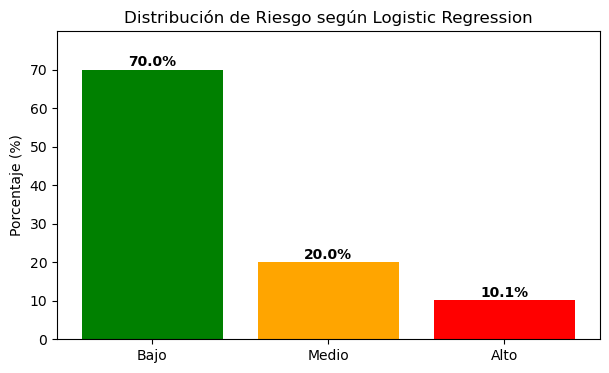

In [19]:
# --- Después de entrenar y guardar probabilidades y categorías ---
#resultados_df = pd.DataFrame(results).sort_values("AUC promedio", ascending=False)
#print("\n===== TABLA DE COMPARACIÓN DE MODELOS =====")
#print(resultados_df)

# Riesgos 
riesgos = y_riesgo_dict["LogisticRegression"]

# Contamos la cantidad de cada categoría, incluyendo "Nulo"
counts = pd.Series(riesgos).value_counts(normalize=True) * 100

# Gráfico de barras con colores asignados a cada categoría
colores = {
    "Bajo": "green",
    "Medio": "orange",
    "Alto": "red"
}

plt.figure(figsize=(7,4))
bars = plt.bar(counts.index, counts.values, color=[colores.get(cat, "blue") for cat in counts.index])
plt.ylabel("Porcentaje (%)")
plt.title("Distribución de Riesgo según Logistic Regression")

# Etiquetas de porcentaje sobre cada barra
for i, v in enumerate(counts.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

plt.ylim(0, max(counts.values) + 10)
plt.show()

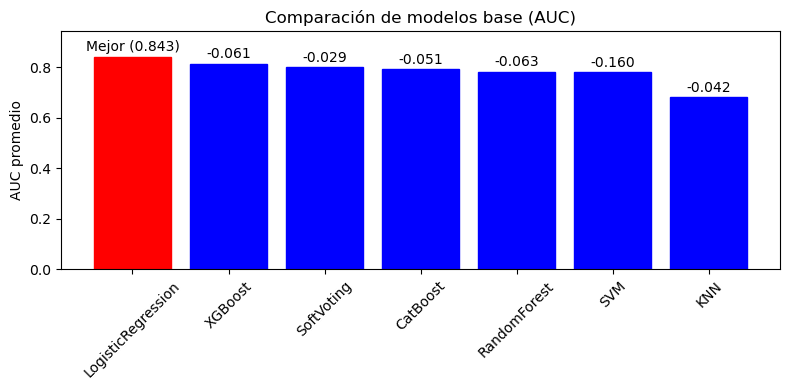

In [20]:
# encontrar índice del mejor modelo
best_idx = resultados_df["AUC promedio"].idxmax()
best_auc = resultados_df.loc[best_idx, "AUC promedio"]

plt.figure(figsize=(8,4))
bars = plt.bar(resultados_df["Modelo"], resultados_df["AUC promedio"])

# pintar todas las barras en azul y la mejor en rojo
for i, bar in enumerate(bars):
    auc = resultados_df.loc[i, "AUC promedio"]
    if i == best_idx:
        bar.set_color("red")  # mejor modelo
        label = f"Mejor ({auc:.3f})"
    else:
        bar.set_color("blue")  # resto
        diff = best_auc - auc
        label = f"-{diff:.3f}"  # diferencia con el mejor

    # agregar la etiqueta sobre la barra
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, label, 
             ha='center', va='bottom', fontsize=10)

# aumentar el margen superior del gráfico
plt.ylim(0, best_auc + 0.1)  # 0.1 extra para dar espacio a las etiquetas

plt.title("Comparación de modelos base (AUC)")
plt.ylabel("AUC promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

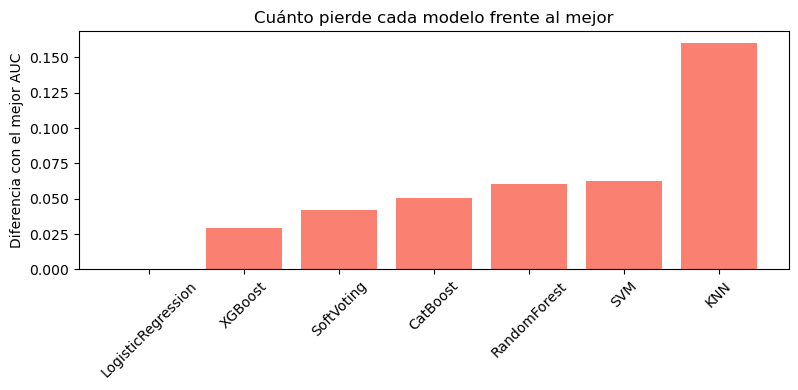

In [21]:
best_auc = resultados_df["AUC promedio"].max()
diff = best_auc - resultados_df["AUC promedio"]

plt.figure(figsize=(8,4))
plt.bar(resultados_df["Modelo"], diff, color='salmon')
plt.xticks(rotation=45)
plt.ylabel("Diferencia con el mejor AUC")
plt.title("Cuánto pierde cada modelo frente al mejor")
plt.tight_layout()
plt.show()

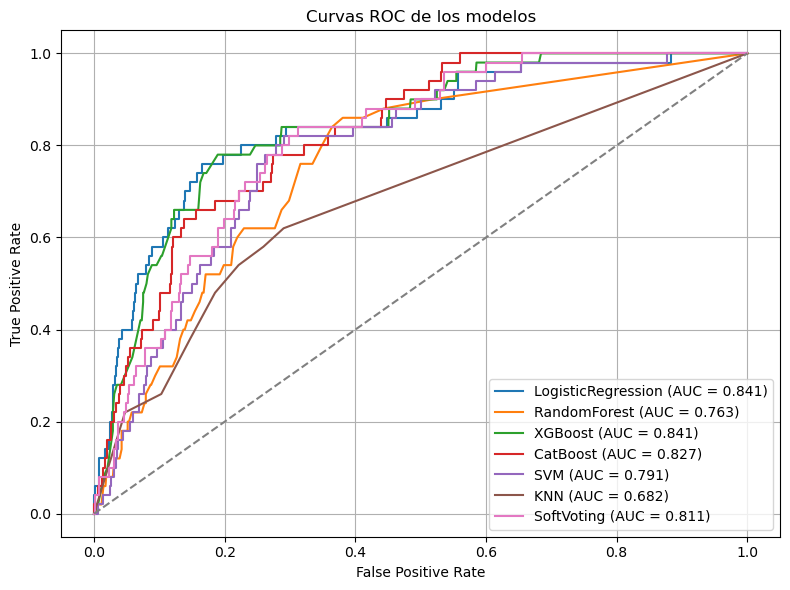

In [22]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(8,6))
for modelo in y_pred_proba:
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba[modelo])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{modelo} (AUC = {roc_auc:.3f})')

plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC de los modelos')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
#Evaluar Logistic Regression SIN SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline
import numpy as np

pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, 
                                 random_state=RANDOM_STATE,
                                 class_weight='balanced'))
])

scores_lr = cross_val_score(pipe_lr, X_train, y_train, 
                            cv=5, scoring='roc_auc')

print("LR sin SMOTE: AUC mean =", scores_lr.mean(), 
      "std =", scores_lr.std())

LR sin SMOTE: AUC mean = 0.8406384851050662 std = 0.02446409271011319


In [24]:
#Obtengo los mejores hiperparametros
from sklearn.model_selection import GridSearchCV

lr_grid = {
    "model__penalty": ["l1", "l2"],
    "model__C": [0.1, 1, 3, 10],
    "model__solver": ["liblinear"]   # necesario para L1
}

pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, 
                                 random_state=RANDOM_STATE,
                                 class_weight='balanced'))
])

grid = GridSearchCV(pipe_lr, lr_grid, cv=5, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best LR params:", grid.best_params_)
print("Best LR AUC:", grid.best_score_)

Best LR params: {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best LR AUC: 0.8428988762343519


In [25]:
# Entreno el modelo final con los mejores hiperparámetros sobre todo el train
best_lr = grid.best_estimator_
best_lr.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
from sklearn.metrics import roc_auc_score

y_pred_proba = best_lr.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_pred_proba)

print("AUC en TEST:", auc_test)

# Si tu AUC en test es similar (ej: 0.83–0.84), está validado

AUC en TEST: 0.8409670781893004


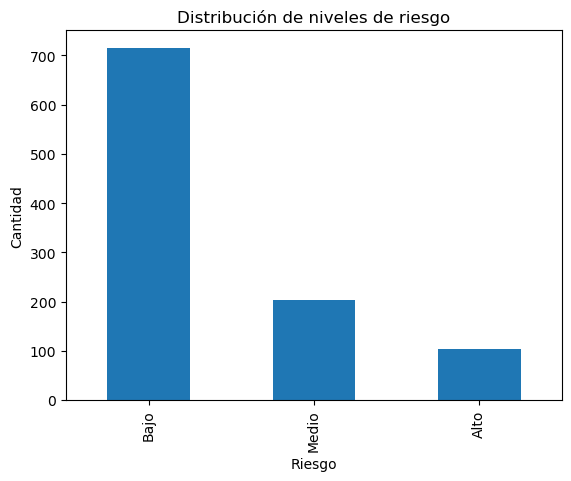

In [27]:
import pandas as pd

df_results = pd.DataFrame({
    "y_test": y_test,
    "prob": y_pred_proba
})

# corte por percentiles
p70 = np.percentile(y_pred_proba, 70)
p90 = np.percentile(y_pred_proba, 90)

def categorizar(prob):
    if prob < p70:
        return "Bajo"
    elif prob < p90:
        return "Medio"
    else:
        return "Alto"

df_results["riesgo"] = df_results["prob"].apply(categorizar)

df_results["riesgo"].value_counts().reindex(["Bajo","Medio","Alto"]).plot(kind="bar")
plt.title("Distribución de niveles de riesgo")
plt.xlabel("Riesgo")
plt.ylabel("Cantidad")
plt.show()

Threshold óptimo para screening: 0.17847279209605568
Matriz de confusión:
 [[465 507]
 [  5  45]]


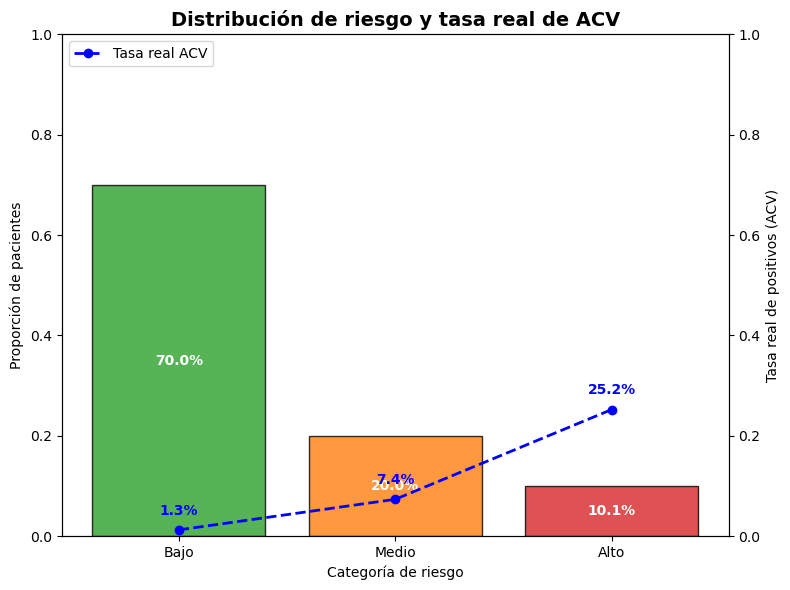

In [33]:
from sklearn.metrics import precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ================================
# Percentiles de riesgo
# ================================
p70 = np.percentile(y_pred_proba, 70)
p90 = np.percentile(y_pred_proba, 90)

def categorizar_riesgo(prob):
    if prob < p70:
        return "Bajo"
    elif prob < p90:
        return "Medio"
    else:
        return "Alto"


# ================================
# Threshold óptimo para screening
# ================================
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Thresholds con recall >= 0.90
thr_candidates = thresholds[recall[:-1] >= 0.90]

best_threshold = thr_candidates.max() if len(thr_candidates) > 0 else 0.5
print("Threshold óptimo para screening:", best_threshold)

# Predicción binaria con el threshold óptimo
y_pred_screening = (y_pred_proba >= best_threshold).astype(int)

print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred_screening))


# ================================
# DataFrame final de resultados
# ================================
df_resultados = pd.DataFrame({
    "y_real": y_test.values,
    "probabilidad": y_pred_proba,
    "pred_binaria": y_pred_screening
})

# Agrego categoría de riesgo
df_resultados["riesgo"] = df_resultados["probabilidad"].apply(categorizar_riesgo)


# ================================
# Gráfico final de riesgo
# ================================
categorias = ["Bajo", "Medio", "Alto"]
colores = ["#2ca02c", "#ff7f0e", "#d62728"]  # verde, naranja, rojo

proporciones = df_resultados["riesgo"].value_counts(normalize=True).reindex(categorias)
tasas_positivos = [
    df_resultados[df_resultados["riesgo"] == nivel]["y_real"].mean()
    for nivel in categorias
]

fig, ax1 = plt.subplots(figsize=(8,6))

# Barras: proporción en cada riesgo
bars = ax1.bar(categorias, proporciones.values, color=colores, alpha=0.8, edgecolor="black")
ax1.set_ylabel("Proporción de pacientes")
ax1.set_xlabel("Categoría de riesgo")
ax1.set_ylim(0, 1)
ax1.set_title("Distribución de riesgo y tasa real de ACV", fontsize=14, fontweight="bold")

# Etiquetas dentro de las barras
for bar, prop in zip(bars, proporciones.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
             f"{prop*100:.1f}%", ha='center', va='center', color="white", fontweight="bold")

# Línea: tasa real de ACV
ax2 = ax1.twinx()
ax2.plot(categorias, tasas_positivos, marker='o', linestyle='--', linewidth=2, color='blue', label="Tasa real ACV")
ax2.set_ylabel("Tasa real de positivos (ACV)")
ax2.set_ylim(0, 1)

# Etiquetas de cada punto
for i, t in enumerate(tasas_positivos):
    ax2.text(i, t + 0.03, f"{t*100:.1f}%", ha='center', color='blue', fontsize=10, fontweight="bold")

ax2.legend(loc="upper left")
plt.tight_layout()
plt.show()